In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
base_dir = Path('/mnt/raidbio2/extstud/praktikum/genprakt-ws25/sc_data')

counts_200_bp = pd.read_csv(base_dir / 'ref_last200_bp_counts.tsv', sep='\t', header=None, names=['transcript_id', 'count'])
counts_100_bp = pd.read_csv(base_dir / 'ref_last100_bp_counts.tsv', sep='\t', header=None, names=['transcript_id', 'count'])
counts_both = pd.merge(counts_100_bp, counts_200_bp, on='transcript_id', suffixes=('_100bp', '_200bp'),how='outer')
print(counts_100_bp.shape)
print(counts_200_bp.shape)
print(counts_both.shape)
counts_both['count_100bp'] = counts_both['count_100bp'].fillna(0)
counts_both.head()

PermissionError: [Errno 13] Permission denied: '/mnt/raidbio2/extstud/praktikum/genprakt-ws25/sc_data/ref_last200_bp_counts.tsv'

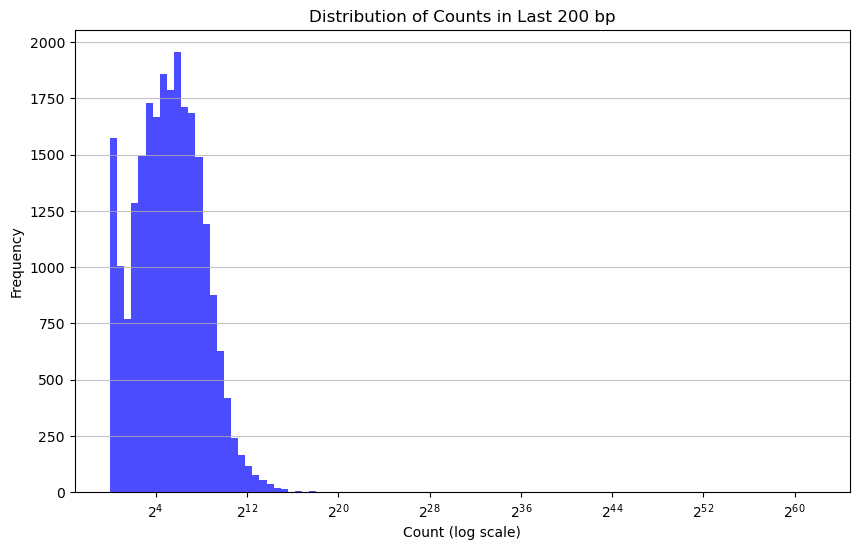

In [8]:
fig = plt.figure(figsize=(10, 6))
bins = np.logspace(np.log2(counts_200_bp['count'].min()), np.log2(counts_200_bp['count'].max()), 100)
plt.hist(counts_200_bp['count'], bins=bins, color='blue', alpha=0.7)
plt.xscale('log', base=2)
plt.title('Distribution of Counts in Last 200 bp')
plt.xlabel('Count (log scale)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

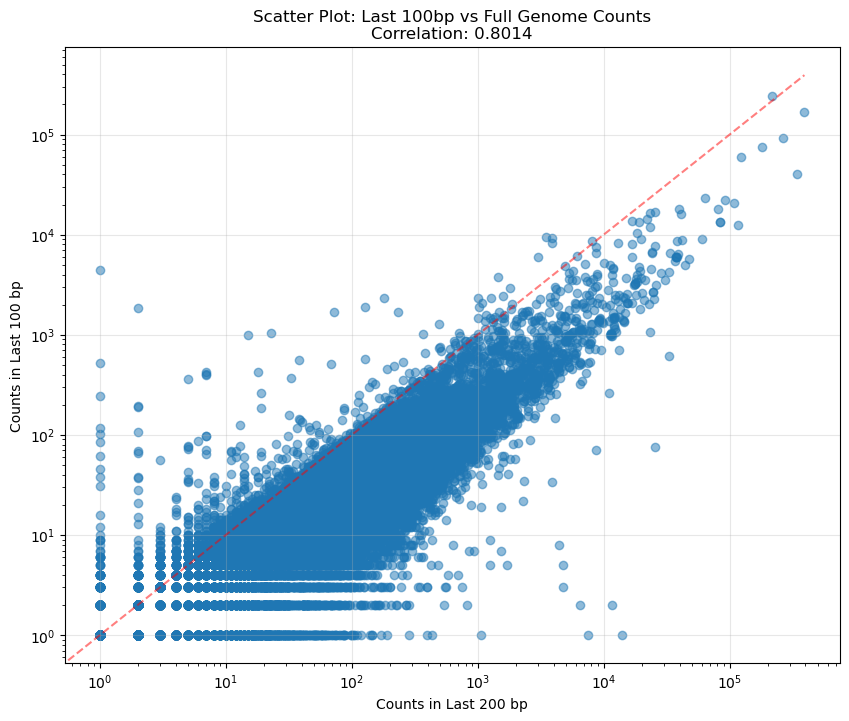

In [23]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(counts_both['count_200bp'], counts_both['count_100bp'], alpha=0.5)
correlation = counts_both[['count_200bp', 'count_100bp']].corr().iloc[0, 1]
plt.xlabel('Counts in Last 200 bp')
plt.ylabel('Counts in Last 100 bp')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.title('Scatter Plot of Counts in Last 200 bp vs Last 100 bp')
plt.grid(True, alpha=0.3)
plt.title(f'Scatter Plot: Last 100bp vs Full Genome Counts\nCorrelation: {correlation:.4f}')
# Add diagonal reference line
min_val = min(counts_both['count_200bp'].min(), counts_both['count_100bp'].min())
max_val = max(counts_both['count_200bp'].max(), counts_both['count_100bp'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
plt.show()

In [3]:
fullgenome_counts = pd.read_csv(base_dir / "full_genome_transcript_counts.txt", sep='\t', comment='#')

fullgenome_counts.rename(columns={fullgenome_counts.columns[-1]: 'counts'}, inplace=True)
fullgenome_counts = fullgenome_counts[['Geneid', 'counts']]
fullgenome_counts = fullgenome_counts[(fullgenome_counts['counts'] > 200) & (fullgenome_counts['counts'] < 250)]

fullgenome_counts.head(20)


PermissionError: [Errno 13] Permission denied: '/mnt/raidbio2/extstud/praktikum/genprakt-ws25/sc_data/full_genome_transcript_counts.txt'

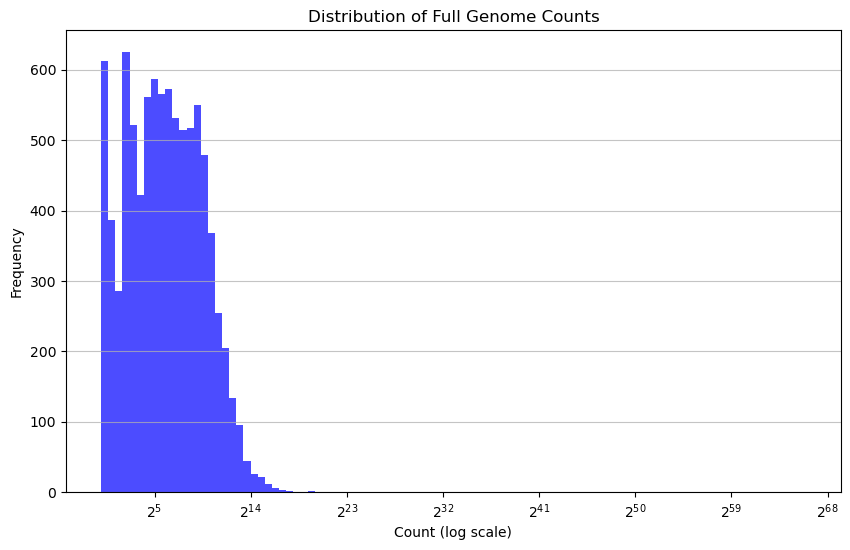

In [26]:
fig = plt.figure(figsize=(10, 6))
bins = np.logspace(np.log2(fullgenome_counts['counts'].min() + 1), np.log2(fullgenome_counts['counts'].max()), 100)
plt.hist(fullgenome_counts['counts'], bins=bins, color='blue', alpha=0.7)
plt.xscale('log', base=2)
plt.title('Distribution of Full Genome Counts')
plt.xlabel('Count (log scale)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Pearson Correlation: 0.5590


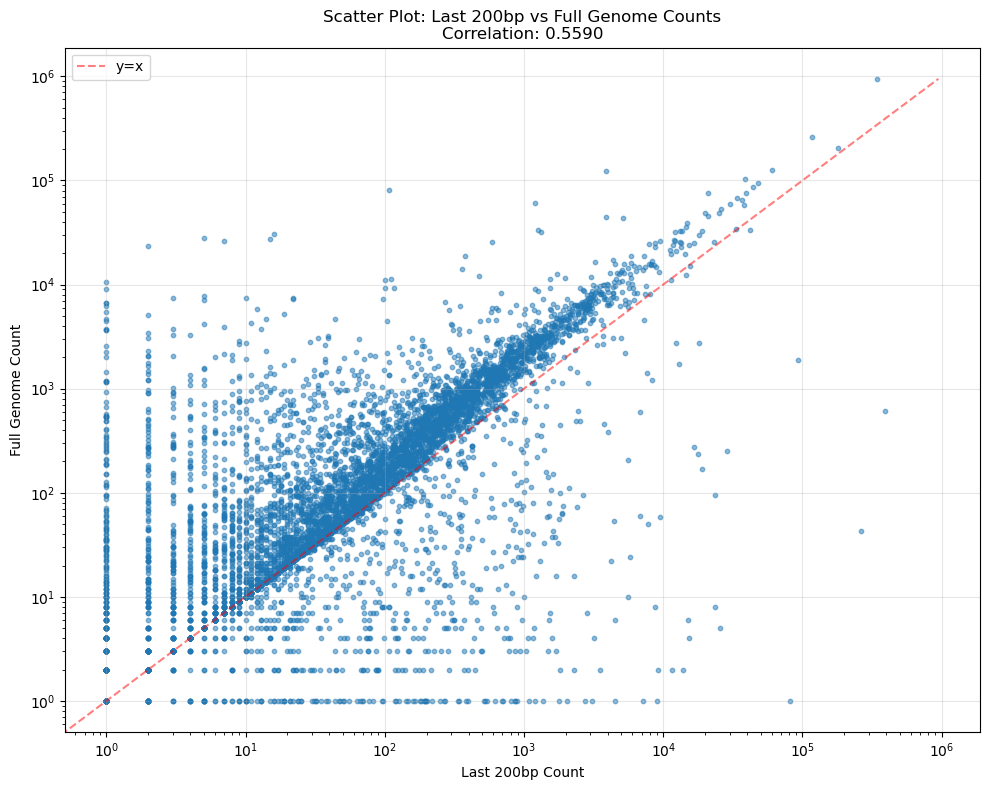

In [26]:
# Merge the two datasets
merged = counts_200_bp.merge(fullgenome_counts[['Geneid', 'counts']], 
                              left_on='transcript_id', 
                              right_on='Geneid', 
                              how='inner')

# Calculate correlation
correlation = merged['count'].corr(merged['counts'])
print(f'Pearson Correlation: {correlation:.4f}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged['count'], merged['counts'], alpha=0.5, s=10)
ax.set_xlabel('Last 200bp Count')
ax.set_ylabel('Full Genome Count')
ax.set_title(f'Scatter Plot: Last 200bp vs Full Genome Counts\nCorrelation: {correlation:.4f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
min_val = min(merged['count'].min(), merged['counts'].min())
max_val = max(merged['count'].max(), merged['counts'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
ax.legend()

plt.tight_layout()
plt.show()

Pearson Correlation: 0.1867


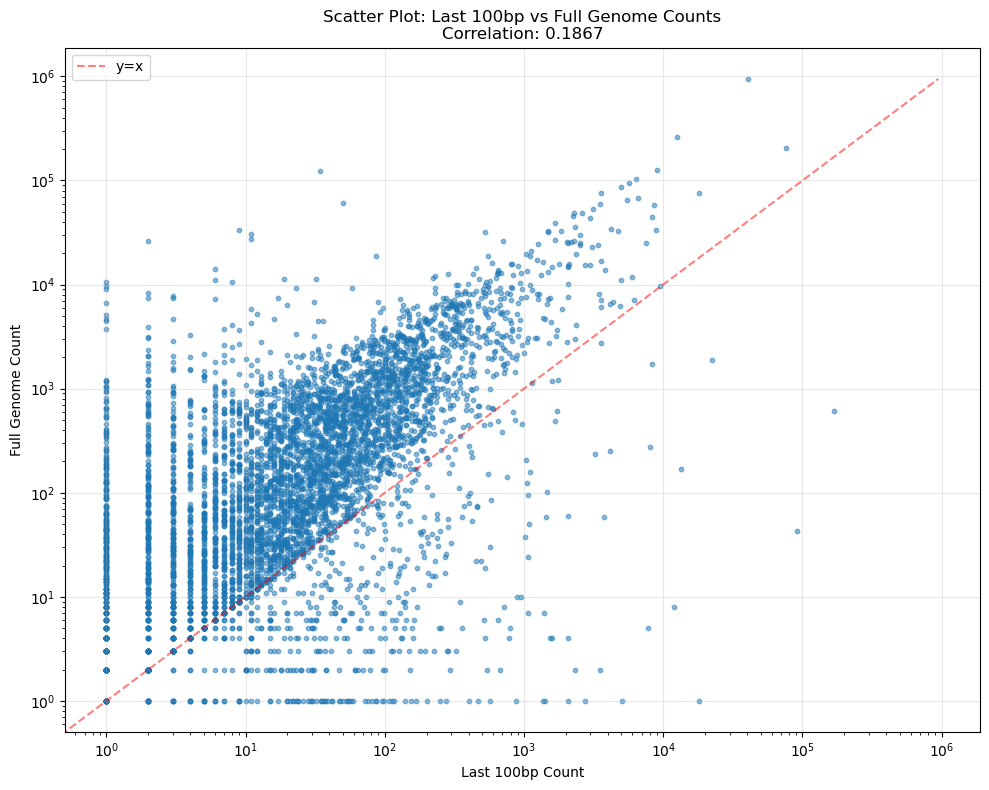

In [28]:
# Merge the two datasets
merged = counts_100_bp.merge(fullgenome_counts[['Geneid', 'counts']], 
                              left_on='transcript_id', 
                              right_on='Geneid', 
                              how='inner')

# Calculate correlation
correlation = merged['count'].corr(merged['counts'])
print(f'Pearson Correlation: {correlation:.4f}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged['count'], merged['counts'], alpha=0.5, s=10)
ax.set_xlabel('Last 100bp Count')
ax.set_ylabel('Full Genome Count')
ax.set_title(f'Scatter Plot: Last 100bp vs Full Genome Counts\nCorrelation: {correlation:.4f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
min_val = min(merged['count'].min(), merged['counts'].min())
max_val = max(merged['count'].max(), merged['counts'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
ax.legend()

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd 

star_last_k_counts = pd.read_csv('../data/coverage_tsv/all_k_counts.tsv', sep='\t', header = 0)
star_last_k_counts.head()



,transcript_id,k100_count,k200_count,k300_count,k400_count,k500_count,k600_count,k700_count,k800_count,k900_count,...,k1100_count,k1200_count,k1300_count,k1400_count,k1500_count,k1600_count,k1700_count,k1800_count,k1900_count,k2000_count
0,ENSSSCT00000000003,724,834,934,1034,36,136,35,90,33,...,2,23,123,223,323,27,127,52,152,252
1,ENSSSCT00000000004,6334,34215,50440,52847,72,172,272,30,47,...,87,21,39,40,20,44,144,70,170,16
2,ENSSSCT00000000006,373,1554,2746,2746,2746,2746,2746,2746,2746,...,2746,2746,3513,4245,4730,4730,5007,15557,52259,80736
3,ENSSSCT00000000007,0,153,153,153,153,153,153,153,153,...,153,153,153,153,153,153,153,153,153,153
4,ENSSSCT00000000008,8818,59661,118650,140631,499,43,143,98,30,...,3,103,80,73,7,107,135,135,135,135


Loaded last_100_bp.tsv
Loaded last_200_bp.tsv
Loaded last_300_bp.tsv
Loaded last_400_bp.tsv
Loaded last_500_bp.tsv
Loaded last_600_bp.tsv
Loaded last_700_bp.tsv
Loaded last_800_bp.tsv
Loaded last_900_bp.tsv
Loaded last_1000_bp.tsv
Loaded last_1100_bp.tsv
Loaded last_1200_bp.tsv
Loaded last_1300_bp.tsv
Loaded last_1400_bp.tsv
Loaded last_1500_bp.tsv
Loaded last_1600_bp.tsv
Loaded last_1700_bp.tsv
Loaded last_1800_bp.tsv
Loaded last_1900_bp.tsv
Loaded last_2000_bp.tsv


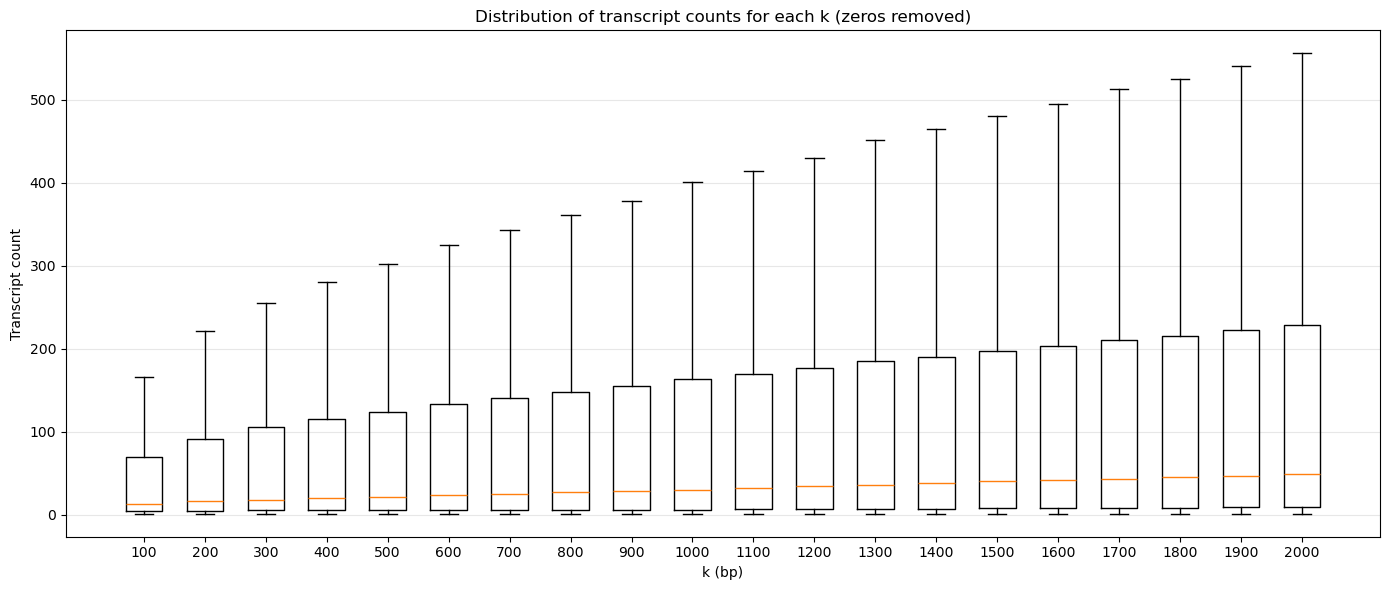

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Directory containing the TSV files
coverage_dir = Path('../data/coverage_spaceranger')

# Mapping: k -> {transcript_id -> summed_count}
counts = {}

# Loop through k values from 100 to 2000 in steps of 100
for k in range(100, 2100, 100):
    counts_k = {}
    tsv_file = coverage_dir / f'last_{k}_bp.tsv'
    if tsv_file.exists():
        # Read transcript-level counts for this k
        df = pd.read_csv(tsv_file, sep='\t', header=0, names=['transcript_id', 'count'])
        for transcript_id, group in df.groupby('transcript_id'):
            counts_k[transcript_id] = counts_k.get(transcript_id, 0) + group['count'].sum()
        
        counts[k] = counts_k
        print(f"Loaded {tsv_file.name}")
# Boxplots: transcript count distribution for each k (filter out count == 0)
k_values = sorted(counts.keys())
filtered_k_values = []
boxplot_data = []

for k in k_values:
    values = [v for v in counts[k].values() if v != 0]
    if values:
        filtered_k_values.append(k)
        boxplot_data.append(values)

if boxplot_data:
    fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
    ax.boxplot(boxplot_data, positions=filtered_k_values, widths=60, showfliers=False)
    ax.set_xlabel('k (bp)')
    ax.set_ylabel('Transcript count')
    ax.set_title('Distribution of transcript counts for each k (zeros removed)')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('No non-zero transcript counts found to plot.')

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
    # Loop through k values from 100 to 2000 in steps of 100
def get_count_merged_regions(coverage_dir):
    counts = []
    for k in range(100, 2100, 100):
        matches = sorted(coverage_dir.glob(f"*last_{k}_bp_merged.tsv"))
        if not matches:
            continue

        tsv_file = matches[0]
        df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
        counts.append(df['count'].sum())
    return counts 
spaceranger_counts = get_count_merged_regions(Path('../data/coverage_spaceranger_big'))
star_counts = get_count_merged_regions(Path('../data/coverage_tsv'))
human_counts = get_count_merged_regions(Path('../data/coverage_human'))
utr_star_counts = get_count_merged_regions(Path('../data/coverage_utr'))
print(len(utr_star_counts))

/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types

20


/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
/tmp/ipykernel_41300/589605033.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])


In [1]:
fig = plt.figure(figsize=(10, 6), dpi = 100)
k_values = [k for k in range(100, 2100, 100)]
plt.plot(k_values, [c/263361661 * 100 for c in spaceranger_counts], marker='o')
plt.plot(k_values, [c/30708498 * 100 for c in star_counts], marker='o')
plt.plot(k_values, [c/124044099 * 100 for c in human_counts], marker='o')
plt.plot(k_values, [c/30708498 * 100 for c in utr_star_counts], marker='o')
#plt.plot#(k_values, human_counts, marker='o')
#plt.plot(k_values, spaceranger_counts, marker='o')
#plt.plot(k_values, star_counts, marker='o')
plt.xlabel('k (bp)')
plt.legend(['Spaceranger', 'STAR','Human', 'STAR UTR'])
plt.ylabel('percentage counts')
plt.grid(True, alpha=0.3)
plt.title('Read count across all transcripts for different k bases at the end of the transcript')
plt.show()

NameError: name 'plt' is not defined

In [1]:
import pandas as pd 
gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])
gtf.head()

/tmp/ipykernel_20310/2982498334.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])


,seqname,source,feature,start,end,score,strand,frame,attribute
0,1,ensembl,gene,226161299,226217308,.,-,.,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
1,1,ensembl,transcript,226188008,226217308,.,-,.,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
2,1,ensembl,exon,226217188,226217308,.,-,.,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
3,1,ensembl,CDS,226217188,226217253,.,-,0,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
4,1,ensembl,start_codon,226217251,226217253,.,-,0,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."


In [5]:
exons = gtf[gtf['feature'] == 'exon'].copy()
exons['transcript_id'] = exons['attribute'].str.extract(r'transcript_id "([^"]+)"')
bed_format = exons[['seqname', 'start', 'end', 'transcript_id', 'score', 'strand']].copy()
bed_format.loc[:, 'start'] = bed_format['start'] - 1
bed_format.drop(columns=['score'], inplace=True)
bed_format.head()
bed_format.to_csv('../data/exons_for_filtering.bed', sep='\t', header=False, index=False)

In [23]:
# Sort by transcript_id AND genomic position
exons = exons.sort_values(["transcript_id", "seqname", "start", "end"])

introns = []
last_5_introns = []
transcripts_last_5_introns_bigger_than_10k = set()
for tx, group in exons.groupby("transcript_id"):
    if len(group) < 2:
        continue
    
    # Intron starts right after previous exon ends
    starts = group["end"].values[:-1] + 1
    # Intron ends right before next exon starts
    ends = group["start"].values[1:] - 1
    lengths = ends - starts + 1

    introns.extend(lengths)
    # Take only the last 5 introns (or fewer if transcript has less than 5)
    last_5_introns.extend(lengths[-5:])
 # Track transcripts with any intron > 10k bp in the last 5
    if any(x > 10000 for x in lengths[-5:]):
        transcripts_last_5_introns_bigger_than_10k.add(tx)

longer_then_10k = [x for x in last_5_introns if x > 10000]
average_intron_length = sum(last_5_introns) / len(last_5_introns)
print(f"Total introns (all): {len(introns)}")
print(f"Total introns (last 5 per transcript): {len(last_5_introns)}")
print(f"number Introns > 10k bp in the last 5 introns: {len(longer_then_10k)}")
print(f"Percentage > 10k bp: {len(longer_then_10k) / len(last_5_introns):.2%}")
print(f"Average intron length (last 5): {average_intron_length:.1f} bp")

Total introns (all): 499043
Total introns (last 5 per transcript): 196412
number Introns > 10k bp in the last 5 introns: 25555
Percentage > 10k bp: 13.01%
Average intron length (last 5): 6504.8 bp


In [25]:
transcripts = exons[exons["transcript_id"].isin(transcripts_last_5_introns_bigger_than_10k)]
transcripts.shape


(193781, 10)

In [47]:
last_500_bp_regions = pd.read_csv('../data/bedfiles/last_500_bp.bed', sep='\t', header=None, names=["chr", "start", "end", "transcript_id", "score", "strand"])
last_500_bp_regions.head()
intron = []
for tx, region in last_500_bp_regions.groupby('transcript_id'):
    if(len(region) < 2):
        continue
    # Intron starts right after previous exon ends
    starts = region["end"].values[:-1] + 1
    # Intron ends right before next exon starts
    ends = region["start"].values[1:] - 1
    lengths = ends - starts + 1
    introns.extend(lengths)

intron_series = pd.Series(introns)

# Disable scientific notation for this output
pd.options.display.float_format = '{:.2f}'.format
print(intron_series.describe())
# Reset to default
pd.reset_option('display.float_format')

count    575635.00
mean       5158.12
std       16685.85
min           0.00
25%         363.00
50%        1283.00
75%        3619.00
max     1111590.00
dtype: float64


In [ ]:
import pandas as pd 
gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])
utrs = gtf[gtf['feature'] == 'three_prime_utr'].copy()
utrs['transcript_id'] = utrs['attribute'].str.extract(r'transcript_id "([^"]+)"')
utrs['gene_id'] = utrs['attribute'].str.extract(r'gene_id "([^"]+)"')
lenghts= []
gene_mapping = {}
for tx, group in utrs.groupby("transcript_id"):
    length = 0
    for utr in group.itertuples():
        length += utr.end - utr.start + 1
    gene_mapping[tx] = group['gene_id'].iloc[0]
    lenghts.append(length)
#utrs['length'] = utrs['end'] - utrs['start'] + 1
#utrs['length'].describe()
lenghts_series = pd.Series(lenghts)
lenghts_series.describe()

/tmp/ipykernel_41300/3627101713.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])


count    36510.000000
mean      1441.360422
std       1369.734274
min          1.000000
25%        410.000000
50%       1001.000000
75%       2070.750000
max      17391.000000
dtype: float64

In [12]:
from scipy.io import mmread
import numpy as np
kallisto_dir = Path('/mnt/biocluster/praktikum/genprakt-ws25/gruppe_a/data/kallisto_run')

transcript_ids = []
with (kallisto_dir / 'utr_500bp'/ 'utr_last_500.fa').open() as fasta_handle:
    for line in fasta_handle:
        if line.startswith('>'):
            transcript_ids.append(line[1:].strip().split()[0])

ec_matrix = mmread(kallisto_dir /'utr_500bp' / 'output.mtx').tocsr()
ec_counts = np.asarray(ec_matrix.sum(axis=1)).ravel().astype(np.int64)
nonzero_ec_counts = {ec_idx: ec_counts[ec_idx] for ec_idx in np.flatnonzero(ec_counts)}

# Ambiguous equivalence-class counts are added to each compatible transcript.
transcript_totals = np.zeros(len(transcript_ids), dtype=np.int64)
with (kallisto_dir / 'utr_500bp' / 'output.ec.txt').open() as ec_handle:
    for line in ec_handle:
        ec_id_text, tx_index_text = line.rstrip().split('\t')
        ec_count = nonzero_ec_counts.get(int(ec_id_text))
        if ec_count is None:
            continue

        tx_indices = np.fromstring(tx_index_text, sep=',', dtype=np.int64)
        transcript_totals[tx_indices] += ec_count

transcript_count_matrix = pd.DataFrame(
    {
        'transcript_id': transcript_ids,
        'count': transcript_totals,
    }
)
transcript_count_matrix = transcript_count_matrix[transcript_count_matrix['count'] > 0].reset_index(drop=True)
transcript_count_matrix.head()


,transcript_id,count
0,ENSSSCT00000078291,2
1,ENSSSCT00000078294,7
2,ENSSSCT00000078296,4
3,ENSSSCT00000078299,2
4,ENSSSCT00000078280,3


In [18]:
from pathlib import Path
import pandas as pd

datapath = Path('/mnt/biocluster/praktikum/genprakt/gruppe_a')

spaceranger_counts = pd.read_csv(
    datapath / 'data' / 'featureCounts.txt',
    sep='\t',
    comment='#',
    header=0,
    names=['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'count'],
)

star_count = pd.read_csv(
    datapath / 'data' / 'star_counts.txt',
    sep='\t',
    comment='#',
    header=0,
    names=['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'count'],
)

minimap_fullgenome_counts = pd.read_csv(
    datapath / 'sc_count' / 'fullgenome_counts.tsv',
    sep='\t',
    header=1,
    names=['transcript_id', 'count'],
)

minimap_utr_counts = pd.read_csv(
    datapath / 'data' / 'minimap' / 'utr_last500_run' / 'idxstats.tsv',
    sep='\t',
    header=None,
    names=['transcript_id', 'length', 'mapped', 'unmapped'],
)

minimap_fullgenome_short_rna_counts = pd.read_csv(
    datapath / 'data' / 'minimap' / 'full_genome_short_rna_mode_Run' / 'featureCounts.txt',
    sep='\t',
    comment='#',
    header=0,
    names=['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length', 'count']
)

# Standardized count tables used by plot_count_correlation in the last cell
kallisto_counts_std = transcript_count_matrix[['transcript_id', 'count']].rename(columns={'count': 'counts'})
spaceranger_counts_std = spaceranger_counts[['Geneid', 'count']].rename(columns={'Geneid': 'transcript_id', 'count': 'counts'})
star_counts_std = star_count[['Geneid', 'count']].rename(columns={'Geneid': 'transcript_id', 'count': 'counts'})
minimap_fullgenome_counts_std = minimap_fullgenome_counts[['transcript_id', 'count']].rename(columns={'count': 'counts'})
minimap_utr_counts_std = minimap_utr_counts[['transcript_id', 'mapped']].rename(columns={'mapped': 'counts'})
minimap_fullgenome_short_rna_counts = minimap_fullgenome_short_rna_counts[['Geneid', 'count']].rename(columns={'Geneid': 'transcript_id', 'count': 'counts'})

all_counts = {
    'kallisto': kallisto_counts_std,
    'spaceranger': spaceranger_counts_std,
    'star': star_counts_std,
    'minimap_fullgenome': minimap_fullgenome_counts_std,
    'minimap_utr': minimap_utr_counts_std,
    'minimap_fullgenmoe_sr': minimap_fullgenome_short_rna_counts,
}

{name: df.shape for name, df in all_counts.items()}

{'kallisto': (38349, 2),
 'spaceranger': (58674, 2),
 'star': (58674, 2),
 'minimap_fullgenome': (58674, 2),
 'minimap_utr': (58675, 2),
 'minimap_fullgenmoe_sr': (58674, 2)}

In [19]:
import matplotlib.pyplot as plt

def plot_count_correlation(
    df1,
    df2,
    id_col="transcript_id",
    count_col="counts",
    label1="Dataset 1",
    label2="Dataset 2",
    log_scale=True,
):
    """
    Plot correlation between two count tables.

    Expected columns in both dataframes:
      - id_col (default: transcript_id)
      - count_col (default: counts)
    """
    a = df1[[id_col, count_col]].rename(columns={count_col: "count_1"})
    b = df2[[id_col, count_col]].rename(columns={count_col: "count_2"})

    merged = a.merge(b, on=id_col, how="inner")

    if log_scale:
        merged = merged[(merged["count_1"] > 0) & (merged["count_2"] > 0)].copy()

    corr = merged["count_1"].corr(merged["count_2"])
    print(f"Pearson correlation ({label1} vs {label2}): {corr:.4f}")

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(merged["count_1"], merged["count_2"], alpha=0.5, s=10)

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlabel(f"{label1} count")
    ax.set_ylabel(f"{label2} count")
    ax.set_title(f"{label1} vs {label2}\nCorrelation: {corr:.4f}")
    ax.grid(True, alpha=0.3)

    min_val = min(merged["count_1"].min(), merged["count_2"].min())
    max_val = max(merged["count_1"].max(), merged["count_2"].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", alpha=0.6, label="y=x")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return corr, merged

Pearson correlation (Kallisto vs Spaceranger): 0.0047


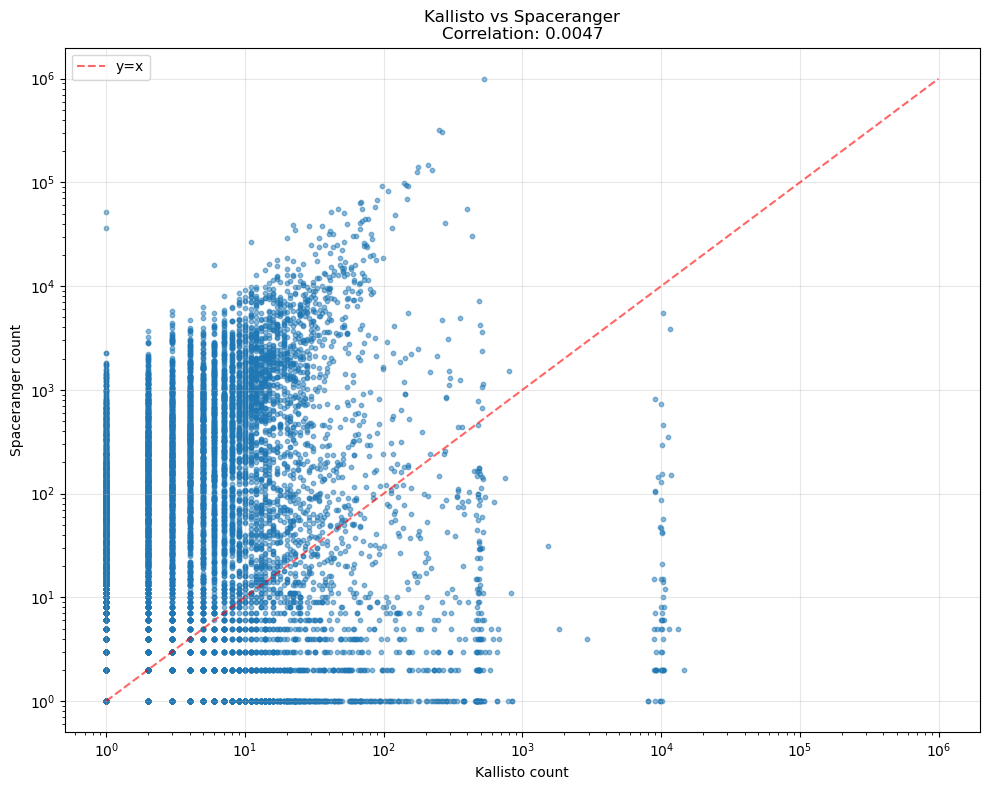

Pearson correlation (STAR vs Spaceranger): 0.9850


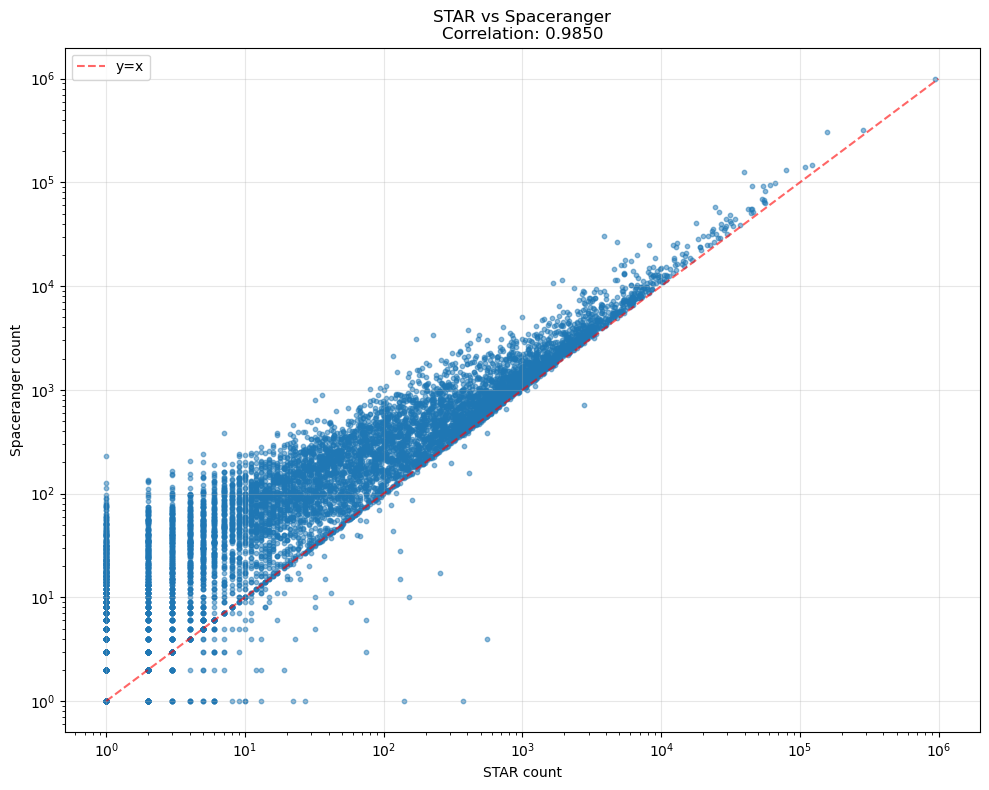

{'kallisto_vs_spaceranger': np.float64(0.004706068894496269),
 'star_vs_spaceranger': np.float64(0.9849819245362524)}

In [24]:
# Run the function from the last cell on all requested comparisons
correlations = {}

correlations['kallisto_vs_spaceranger'], _ = plot_count_correlation(
    kallisto_counts_std, spaceranger_counts_std, label1='Kallisto', label2='Spaceranger'
 )

correlations['star_vs_spaceranger'], _ = plot_count_correlation(
    star_counts_std, spaceranger_counts_std, label1='STAR', label2='Spaceranger'
 )
'''
correlations['fullgenome_vs_star'], _ = plot_count_correlation(
    minimap_fullgenome_counts_std, star_counts_std, label1='Fullgenome', label2='STAR'
 )

correlations['fullgenome_vs_minimap_utr'], _ = plot_count_correlation(
    minimap_fullgenome_counts_std, minimap_utr_counts_std, label1='Minimap fullgenome', label2='Minimap UTR'
 )

correlations['minimap_utr_vs_star'], _ = plot_count_correlation(
    minimap_utr_counts_std, star_counts_std, label1='Minimap UTR', label2='STAR'
 )

correlations['minimap_sr_vs_minimap_normal'], _ = plot_count_correlation(
    minimap_fullgenome_counts_std , minimap_fullgenome_short_rna_counts, label1='minimap normal', label2='minimap short read rna mode'
)
correlations['minimap_sr_vs_star'], _ = plot_count_correlation(
    minimap_fullgenome_short_rna_counts, star_counts_std, label1='Minimap short read rna mapping', label2='Star'
)
correlations['minimap_sr_vs_minimap_utr'], _ = plot_count_correlation(
    minimap_utr_counts_std, minimap_fullgenome_short_rna_counts, label1='minimap with UTR' , label2 = 'minimap short read rna mode'
)
'''
correlations

In [34]:

star_only_counts = star_count.drop(columns=['Chr', 'Start', 'End', 'Strand', 'Length'], inplace=False)
merged = star_only_counts.merge(spaceranger_counts, left_on='Geneid', right_on='Geneid', how='inner', suffixes=('_star', '_spaceranger'))
candidates = merged[(merged['count_star'] > 10) & (merged['count_star'] < 100) & (merged['count_spaceranger'] > 100)]
candidates['difference'] = candidates['count_spaceranger'] - candidates['count_star']
candidates = candidates.sort_values('difference', ascending=False)
candidates.head(20)

/tmp/ipykernel_24230/4028662491.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates['difference'] = candidates['count_spaceranger'] - candidates['count_star']


,Geneid,count_star,Chr,Start,End,Strand,Length,count_spaceranger,difference
14485,ENSSSCT00000071282,94,6;6;6;6;6;6;6;6;6,84735253;84746967;84751716;84752298;84752481;8...,84735922;84751713;84751894;84752335;84752592;8...,-;-;-;-;-;-;-;-;-,6205,1036,942
12968,ENSSSCT00000046403,80,6;6;6;6;6;6;6;6;6;6,54655414;54662913;54663241;54664093;54671494;5...,54655458;54663029;54663374;54664571;54671619;5...,+;+;+;+;+;+;+;+;+;+,1874,1012,932
48237,ENSSSCT00000023238,36,5;5;5,63088778;63092400;63098526,63092397;63092637;63098750,-;-;-,4083,894,858
25430,ENSSSCT00000017250,91,15;15;15;15;15;15;15,54296113;54310541;54312530;54315071;54315269;5...,54296260;54310750;54312703;54315160;54315430;5...,+;+;+;+;+;+;+,1602,898,807
33083,ENSSSCT00000008947,32,3;3;3;3,53289994;53290349;53291612;53294790,53290060;53290461;53291737;53295304,-;-;-;-,821,801,769
44894,ENSSSCT00000058238,83,7;7;7,30561765;30561924;30562074,30561890;30562033;30562221,-;-;-,384,798,715
51329,ENSSSCT00000012005,79,10;10;10;10;10;10;10;10;10;10;10;10,32139063;32140261;32140597;32140814;32141262;3...,32139456;32140343;32140693;32140933;32141403;3...,-;-;-;-;-;-;-;-;-;-;-;-,1648,777,698
31141,ENSSSCT00000090662,98,8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8,30192033;30201628;30214835;30229619;30229850;3...,30192050;30201983;30214922;30229732;30229956;3...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+,5752,787,689
50735,ENSSSCT00000050844,88,11;11;11;11,4746403;4747020;4747176;4748186,4746643;4747076;4747255;4748893,+;+;+;+,1086,776,688
25220,ENSSSCT00000049692,94,15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;1...,59141639;59145189;59148401;59149028;59162535;5...,59145158;59145795;59148569;59149144;59162649;5...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,8938,762,668
